## Importy

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import json

## Načtení planet ze souboru 

In [46]:
def soubor_planet():

    with open("data/planets.json", "r") as f:
        planety = json.load(f)

    for nazev, p in planety.items():
        p["position"] = np.array(p["position"], dtype=float)
        p["velocity"] = np.array(p["velocity"], dtype=float)

    return planety
planety = soubor_planet()
print(planety)

{'Sun': {'position': array([0., 0.]), 'velocity': array([-0.,  0.]), 'mass': 1.989e+30}, 'Mercury': {'position': array([4.67155116e+10, 3.42218282e+10]), 'velocity': array([-28011.35845288,  38237.72741187]), 'mass': 3.301e+23}, 'Venus': {'position': array([-8.68691682e+10, -6.45206955e+10]), 'velocity': array([ 20869.11256792, -28097.68924   ]), 'mass': 4.867e+24}, 'Earth': {'position': array([1.27259230e+11, 7.86422998e+10]), 'velocity': array([-15665.60088353,  25350.12719806]), 'mass': 5.972e+24}, 'Mars': {'position': array([-6.63216685e+10,  2.18074639e+11]), 'velocity': array([-23057.27941682,  -7012.26538965]), 'mass': 6.417e+23}, 'Jupiter': {'position': array([-7.1148528e+11,  3.1610827e+11]), 'velocity': array([ -5278.30234275, -11880.21567054]), 'mass': 1.898e+27}, 'Saturn': {'position': array([-1.36666939e+12, -4.18786550e+11]), 'velocity': array([ 2824.3452434, -9216.9774843]), 'mass': 5.683e+26}, 'Uranus': {'position': array([2.80477208e+12, 6.11499779e+11]), 'velocity': a

## Fyzika - funkce na výpočet zrychlení

In [52]:
def vypocti_zrychleni(planety):
    G = 6.67430e-11
    zrychleni = {nazev: np.array([0.0, 0.0]) for nazev in planety}

    for nazev_i, p_i in planety.items():
        for nazev_j, p_j in planety.items():
            if nazev_i == nazev_j:
                continue

            rozdil = p_j["position"] - p_i["position"]
            r = np.linalg.norm(rozdil)
            velikost = G * p_j["mass"] * p_i["mass"] / r**2
            sila = velikost * (rozdil / r)
            zrychleni[nazev_i] += sila / p_i["mass"]
    return zrychleni
planety=soubor_planet()
zrychleni = vypocti_zrychleni(planety)
print(zrychleni)

{'Sun': array([-2.09790289e-07,  7.69628825e-08]), 'Mercury': array([-0.03193462, -0.02339376]), 'Venus': array([0.00910137, 0.00676018]), 'Earth': array([-0.00504625, -0.00311828]), 'Mars': array([ 0.00074315, -0.00244455]), 'Jupiter': array([ 2.00123965e-04, -8.89542477e-05]), 'Saturn': array([6.22102088e-05, 1.91337738e-05]), 'Uranus': array([-1.57511009e-05, -3.43384321e-06]), 'Neptune': array([-6.29379088e-06,  1.87401648e-06])}


## Simulace pohybu v určitém čase

In [56]:
def simluj_planety(planety, pocet_kroku, dt):
    historie = {nazev: [] for nazev in planety}

    for krok in range(pocet_kroku):
        zrychleni = vypocti_zrychleni(planety)

        for nazev, p in planety.items():
            p["velocity"] += zrychleni[nazev] * dt
            p["position"] += p["velocity"] * dt
            historie[nazev].append(p["position"].copy())

    return historie

planety = soubor_planet()
historie = simluj_planety(planety, 365, 60*60*24)
print(historie["Earth"])


[array([1.25868052e+11, 8.08092730e+10]), array([1.24439599e+11, 8.29523162e+10]), array([1.22974278e+11, 8.50707841e+10]), array([1.21472507e+11, 8.71640378e+10]), array([1.19934715e+11, 8.92314455e+10]), array([1.18361342e+11, 9.12723826e+10]), array([1.16752840e+11, 9.32862317e+10]), array([1.15109672e+11, 9.52723830e+10]), array([1.13432309e+11, 9.72302346e+10]), array([1.11721236e+11, 9.91591922e+10]), array([1.09976946e+11, 1.01058670e+11]), array([1.08199945e+11, 1.02928090e+11]), array([1.06390747e+11, 1.04766884e+11]), array([1.04549876e+11, 1.06574491e+11]), array([1.02677869e+11, 1.08350359e+11]), array([1.00775268e+11, 1.10093946e+11]), array([9.88426292e+10, 1.11804719e+11]), array([9.68805157e+10, 1.13482153e+11]), array([9.48895006e+10, 1.15125736e+11]), array([9.28701663e+10, 1.16734963e+11]), array([9.08231042e+10, 1.18309338e+11]), array([8.87489143e+10, 1.19848378e+11]), array([8.66482057e+10, 1.21351610e+11]), array([8.45215957e+10, 1.22818568e+11]), array([8.236970

## Vykreslení trajektorie

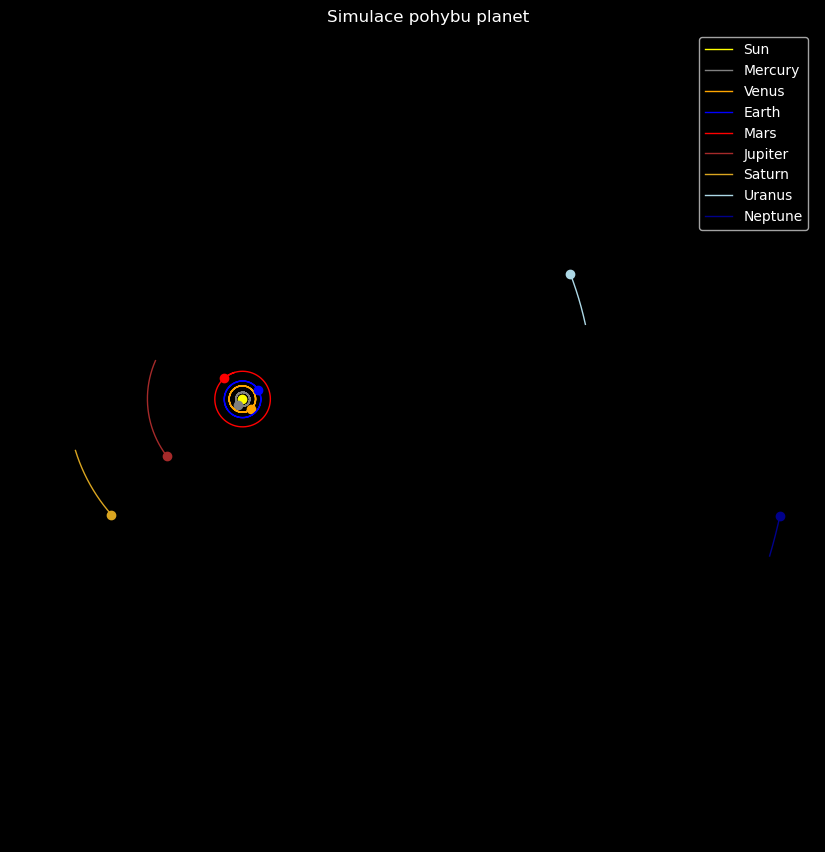

In [57]:
barvy = {
    "Sun": "yellow",
    "Mercury": "gray",
    "Venus": "orange",
    "Earth": "blue",
    "Mars": "red",
    "Jupiter": "brown",
    "Saturn": "goldenrod",
    "Uranus": "lightblue",
    "Neptune": "darkblue"
} 

planety = soubor_planet()
historie = simluj_planety(planety, 365*2, 60*60*24)

plt.figure(figsize=(10, 10), facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")

for nazev, p in planety.items():
    body = np.array(historie[nazev])
    barva = barvy.get(nazev)
    plt.plot(body[:, 0], body[:, 1], color=barva, linewidth=1, label=nazev)
    plt.plot(body[-1, 0], body[-1, 1], "o", color=barva, markersize=6)

plt.legend(facecolor="black", labelcolor="white")
plt.title("Simulace pohybu planet", color="white")
plt.axis("equal")
plt.show()

## Pozice planety po určitém čase

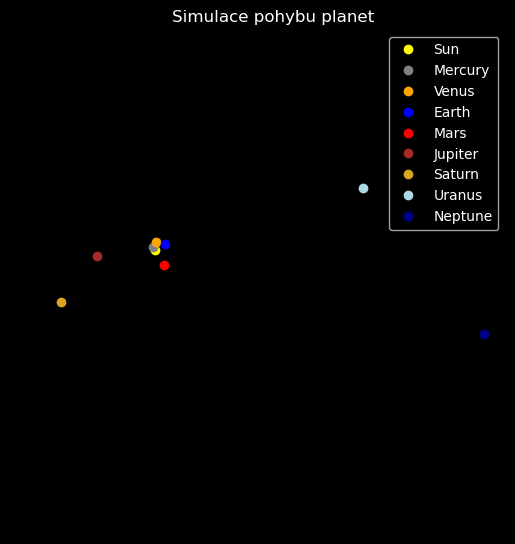

In [58]:
planety = soubor_planet()
historie = simluj_planety(planety, 365, 60*60*24)

plt.figure(figsize=(6, 6), facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")

for nazev, p in planety.items():
    body = np.array(historie[nazev])
    barva = barvy.get(nazev)
    plt.plot(body[-1, 0], body[-1, 1], "o", color=barva, markersize=6,label=nazev)

plt.legend(facecolor="black", labelcolor="white")
plt.title("Simulace pohybu planet", color="white")
plt.axis("equal")
plt.show()